### KNN (K-Nearest Neighbours)

It is supervised learning algorithm used for both regresson and classification

It uses distance formula(Euclidean,Manhatten) to predict the output.

It is a lazy algorithm,during model training it just choose the data.

K - value preferably odd when we are performing classifiation

K = sqrt(n)

n : no of samples

Eucleadian Distance = sqrt((x2-x1)^2 + (y2-y1)^2)

Manhatten Distance = |x2-x1| + |y2-y1|                  : if we have more feature column

x2 , y2 --->input columns

x1 , y1 --->Each sample values

29.688
55.90
50.03
50.80
65.49

266.6

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv('diabetes.csv')

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


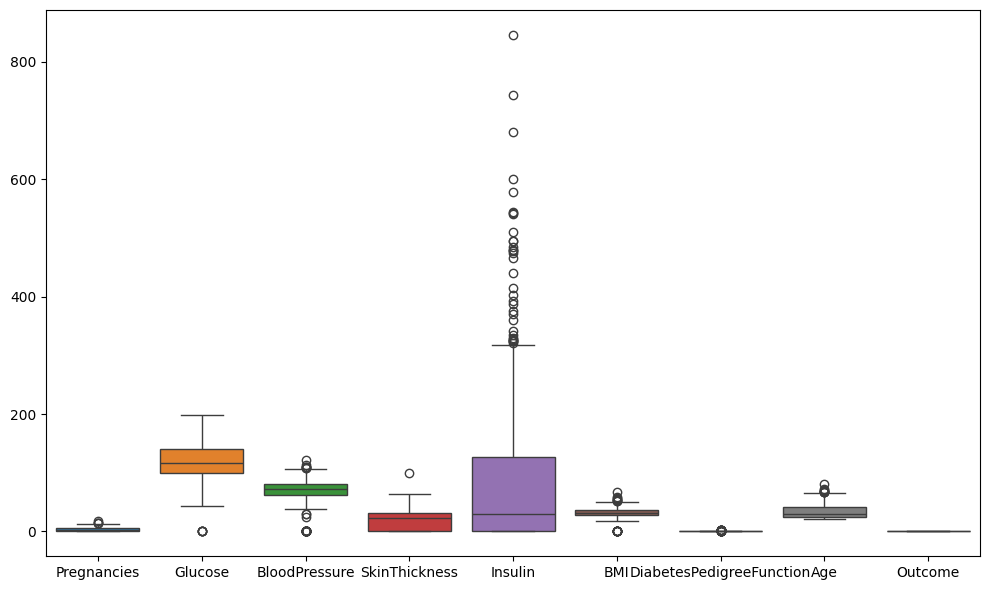

In [4]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.tight_layout()

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [14]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('standard', StandardScaler(), ['Pregnancies', 'Glucose','BloodPressure','SkinThickness','BMI','DiabetesPedigreeFunction','Age']),
#         ('RobustScaler', RobustScaler(), ['Insulin'])
#     ]
# )

preprocessor = ColumnTransformer(
    transformers=[
        (
            'standard',
            StandardScaler(),
            ['Pregnancies', 'Glucose', 'BloodPressure','SkinThickness', 'BMI','DiabetesPedigreeFunction', 'Age']
        ),
        (
            'robust',
            RobustScaler(),
            ['Insulin']
        )
    ]
)

In [22]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [24]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [34]:
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
s=[]

for i in range(10, 31):

    main_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=i,metric='euclidean'))
        ])
    
    main_pipeline.fit(x_train, y_train)
    
    y_pred_test = main_pipeline.predict(x_test)
    
    s.append(accuracy_score(y_test, y_pred_test))

In [36]:
import matplotlib.pyplot as plt

In [45]:
print(s)

[0.6883116883116883, 0.7142857142857143, 0.7207792207792207, 0.7142857142857143, 0.7402597402597403, 0.7337662337662337, 0.7467532467532467, 0.7337662337662337, 0.7532467532467533, 0.7467532467532467, 0.7467532467532467, 0.7532467532467533, 0.7532467532467533, 0.7467532467532467, 0.7402597402597403, 0.7467532467532467, 0.7532467532467533, 0.7532467532467533, 0.7597402597402597, 0.7532467532467533, 0.7337662337662337]


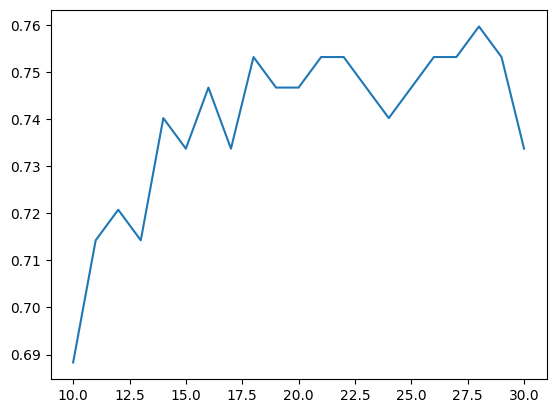

In [47]:
plt.plot(range(10,31),s)

In [26]:
main_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('standard', StandardScaler(),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age']),
                                                 ('robust', RobustScaler(),
                                                  ['Insulin'])])),
                ('classifier', KNeighborsClassifier(metric='euclidean'))])

In [27]:
y_pred_train = main_pipeline.predict(x_train)
y_pred_test = main_pipeline.predict(x_test)

In [28]:
from sklearn.metrics import accuracy_score, classification_report

In [32]:
accuracy_score(y_train, y_pred_train)

0.8192182410423453

In [30]:
accuracy_score(y_test, y_pred_test)

0.7012987012987013